# GeSCF Parameter Sweep

Sweeps all 4 meaningful GeSCF parameters independently, then a combos section.
Run each sweep cell and visually pick whichever config covers the edit cleanly.

| Param | What it does |
|---|---|
| `overlap_frac` | Fraction of a SAM segment that must overlap the initial mask to be included. Lower = bigger mask. |
| `points_per_side` | SAM grid density. Higher = detects thinner/smaller objects. Slower. |
| `pred_iou_thresh` + `stability_score_thresh` | SAM's internal quality filters. Lower = more (noisier) segments pass through. |
| `min_mask_region_area` | Minimum segment size in pixels. Lower = keeps fine details. |

In [49]:
import os, gc
import numpy as np
import torch
import torch.nn.functional as F
import OpenEXR, Imath
from PIL import Image
from pathlib import Path
from scipy import ndimage
from scipy.stats import skew
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from segment_anything.utils.transforms import ResizeLongestSide
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cwd = Path.cwd().resolve()
if (cwd / 'data').exists() and (cwd / 'change_detection_results').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'data').exists() and (cwd.parent / 'change_detection_results').exists():
    PROJECT_ROOT = cwd.parent.resolve()
else:
    raise FileNotFoundError('Run from repo root or change_detection_results/.')

DATASET     = 'depth4'   # ← change dataset here
SAM_WEIGHTS = PROJECT_ROOT / 'weights' / 'sam_vit_b_01ec64.pth'
DATA_DIR    = PROJECT_ROOT / 'data' / DATASET
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device.upper()}  |  Dataset: {DATASET}')
assert SAM_WEIGHTS.exists(), f'SAM weights not found: {SAM_WEIGHTS}'


Device: CUDA  |  Dataset: depth4


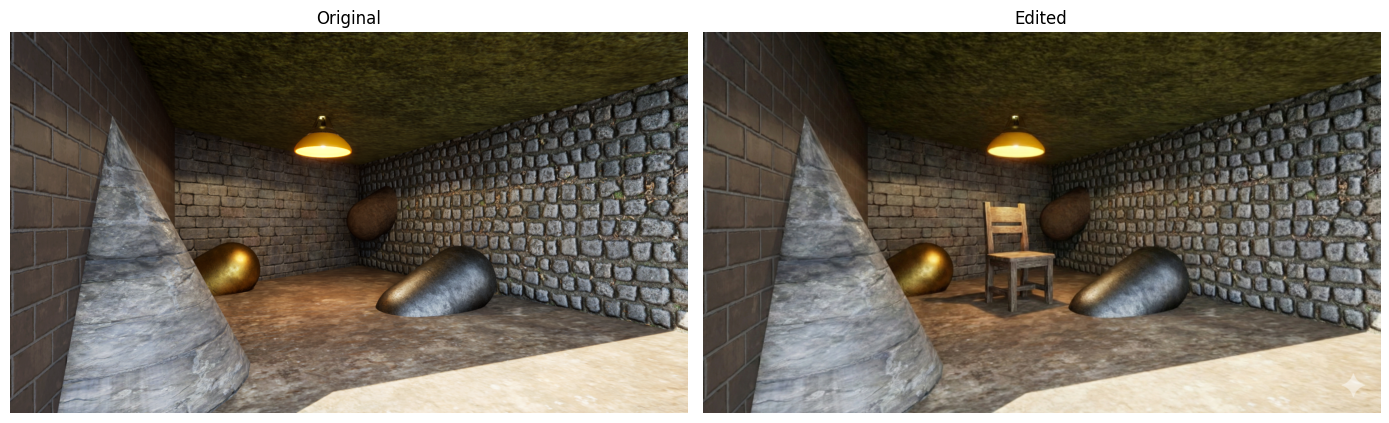

Working at 1526x858


In [50]:
def load_exr_rgb(path):
    exr = OpenEXR.InputFile(str(path))
    dw  = exr.header()['dataWindow']
    w, h = dw.max.x - dw.min.x + 1, dw.max.y - dw.min.y + 1
    FLT = Imath.PixelType(Imath.PixelType.FLOAT)
    rgb = np.stack(
        [np.frombuffer(exr.channel(c, FLT), np.float32).reshape(h, w) for c in 'RGB'],
        axis=-1)
    return Image.fromarray(np.clip(rgb * 255, 0, 255).astype(np.uint8))

def load_image(path):
    p = str(path)
    return load_exr_rgb(p) if p.lower().endswith('.exr') else Image.open(p).convert('RGB')

files       = os.listdir(DATA_DIR)
gt_rgb_path = next(DATA_DIR / f for f in files
                   if f.endswith('.exr') and 'depth' not in f.lower())
edited_path = next(DATA_DIR / f for f in files
                   if 'edit' in f.lower() and f.endswith(('.png', '.jpg', '.exr')))

original_img   = load_image(gt_rgb_path)
edited_img     = load_image(edited_path)
h_img, w_img   = np.array(original_img).shape[:2]
edited_resized = (edited_img.resize((w_img, h_img), Image.BILINEAR)
                  if edited_img.size != original_img.size else edited_img)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(original_img);   axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(edited_resized); axes[1].set_title('Edited');    axes[1].axis('off')
plt.tight_layout(); plt.show()
print(f'Working at {w_img}x{h_img}')


In [51]:
for _v in ('sam', 'hook', 'qkv1', 'qkv2', 'captured', 'f1', 'f2', 'cos_sim'):
    globals().pop(_v, None)
gc.collect()
if device == 'cuda': torch.cuda.empty_cache()

sam = sam_model_registry['vit_b'](checkpoint=str(SAM_WEIGHTS)).to(device).eval()

captured = {}
def _hook_qkv(module, input, output):
    captured['qkv'] = output.detach()
hook = sam.image_encoder.blocks[8].attn.qkv.register_forward_hook(_hook_qkv)

img_size   = sam.image_encoder.img_size
sam_tf     = ResizeLongestSide(img_size)
patch_size = 16
sam_scale  = img_size / max(h_img, w_img)
feat_h     = int(h_img * sam_scale + 0.5) // patch_size
feat_w     = int(w_img * sam_scale + 0.5) // patch_size

def _prep(pil_img):
    t = sam_tf.apply_image(np.array(pil_img))
    return sam.preprocess(
        torch.as_tensor(t, device=device).permute(2, 0, 1).unsqueeze(0).float()
    )

with torch.no_grad():
    sam.image_encoder(_prep(original_img));    qkv1 = captured['qkv']
    sam.image_encoder(_prep(edited_resized));  qkv2 = captured['qkv']
hook.remove()
del _prep, _hook_qkv
captured.clear()

with torch.no_grad():
    f1 = qkv1.squeeze(0);  f2 = qkv2.squeeze(0)
    cos_sim  = (F.normalize(f1, dim=-1) * F.normalize(f2, dim=-1)).sum(dim=-1)
    raw_dist = (1 - cos_sim).cpu().numpy()[:feat_h, :feat_w]
del qkv1, qkv2, f1, f2, cos_sim

raw_dist_full = F.interpolate(
    torch.tensor(raw_dist)[None, None].float(),
    size=(h_img, w_img), mode='bilinear', align_corners=False
).squeeze().numpy()

# Pre-compute normalised distance map at sigma=4 (reused by all sweeps)
_d        = ndimage.gaussian_filter(raw_dist_full, sigma=4)
_d        = (_d - _d.min()) / (_d.max() - _d.min() + 1e-8)
_sk       = skew(_d.ravel())
_k        = float(np.clip(_sk, 1.0, 3.0))
BASE_THR  = float(_d.mean() + _k * _d.std())
BASE_DIST = _d
del _d, _sk, _k

edited_np = np.array(edited_resized)
print(f'Distance map ready.  Baseline threshold: {BASE_THR:.4f}')
print('SAM kept alive for sweep.')


Distance map ready.  Baseline threshold: 0.4260
SAM kept alive for sweep.


In [52]:
def run_gescf(sam_model, edited_np, dist_norm, threshold,
              points_per_side, pred_iou_thresh,
              stability_score_thresh, min_mask_region_area, overlap_frac):
    init     = dist_norm > threshold
    mask_gen = SamAutomaticMaskGenerator(
        sam_model,
        points_per_side=points_per_side,
        pred_iou_thresh=pred_iou_thresh,
        stability_score_thresh=stability_score_thresh,
        min_mask_region_area=min_mask_region_area,
    )
    try:
        segs = mask_gen.generate(edited_np)
    except RuntimeError as e:
        print(f'        SAM error (skipping): {e}')
        return init.copy(), 0, 0, True
    refined    = np.zeros_like(init)
    n_included = 0
    for seg in segs:
        m = seg['segmentation']
        if m.sum() > 0 and np.logical_and(m, init).sum() / m.sum() > overlap_frac:
            refined |= m
            n_included += 1
    if refined.sum() == 0:
        refined = init.copy()
    return refined, len(segs), n_included, False


def show_sweep(results, title, cols=4, baseline_key=None):
    names     = list(results.keys())
    n         = len(names)
    rows      = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 6 * rows))
    axes_flat = axes.flatten() if rows > 1 else np.atleast_1d(axes)
    for i, name in enumerate(names):
        entry       = results[name]
        mask        = entry['mask']
        failed      = entry.get('failed', False)
        n_segs      = entry.get('n_segs', 0)
        n_incl      = entry.get('n_included', 0)
        is_baseline = (name == baseline_key)
        if failed:
            grey = np.full((h_img, w_img, 3), 180, dtype=np.uint8)
            axes_flat[i].imshow(grey)
            axes_flat[i].set_title(f'{name}\nSAM failed', fontsize=11, color='grey')
        else:
            ov = np.zeros((h_img, w_img, 4), dtype=np.float32)
            ov[mask] = [0, 0.45, 1, 0.55] if is_baseline else [1, 0, 0, 0.50]
            axes_flat[i].imshow(edited_resized)
            axes_flat[i].imshow(ov)
            label    = f'{name}  [ref]' if is_baseline else name
            subtitle = f'{mask.mean()*100:.1f}% changed  ({n_incl}/{n_segs} segs)'
            axes_flat[i].set_title(
                f'{label}\n{subtitle}', fontsize=11,
                color='steelblue' if is_baseline else 'black',
                fontweight='bold'  if is_baseline else 'normal',
            )
        axes_flat[i].axis('off')
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


from params import GESCF_BASELINE as BASELINE_PARAMS


_ABBREV = {
    'points_per_side': 'pts',
    'pred_iou_thresh': 'iou',
    'stability_score_thresh': 'stab',
    'min_mask_region_area': 'min_area',
    'overlap_frac': 'overlap',
}

def _fmt_fixed(skip=()):
    """Format fixed-param subtitle, excluding swept keys."""
    return ' | '.join(
        f'{_ABBREV.get(k, k)}={v}'
        for k, v in BASELINE_PARAMS.items()
        if k not in skip
    )

In [53]:
# Run baseline once — shown as reference panel in every sweep
print('Running baseline ...', flush=True)
bl_mask, bl_n_segs, bl_n_incl, bl_failed = run_gescf(
    sam, edited_np, BASE_DIST, BASE_THR, **BASELINE_PARAMS
)
baseline_result = dict(mask=bl_mask, failed=bl_failed, n_segs=bl_n_segs, n_included=bl_n_incl)
print(f'  included={bl_n_incl}/{bl_n_segs}  changed={bl_mask.mean()*100:.1f}%')


Running baseline ...
  included=13/323  changed=2.8%


## Sweep 1 — `overlap_frac`

Focused around the good low-overlap region from your best combo.
Other params: `points_per_side=48`, `pred_iou_thresh=0.55`, `stability_score_thresh=0.65`, `min_area=25`.

Look for the smallest value that still covers the edit cleanly without spilling too far into the background.


[1/7] ovlp=0.08 ...
       included=213/274  changed=75.2%
[2/7] ovlp=0.1 ...
       included=210/274  changed=75.1%
[3/7] ovlp=0.12 ...
       included=209/274  changed=75.0%
[4/7] ovlp=0.15 ...
       included=205/274  changed=25.1%
[5/7] ovlp=0.18 ...
       included=204/274  changed=25.1%
[6/7] ovlp=0.2 ...
       included=204/274  changed=25.1%
[7/7] ovlp=0.25 ...
       included=203/274  changed=25.0%


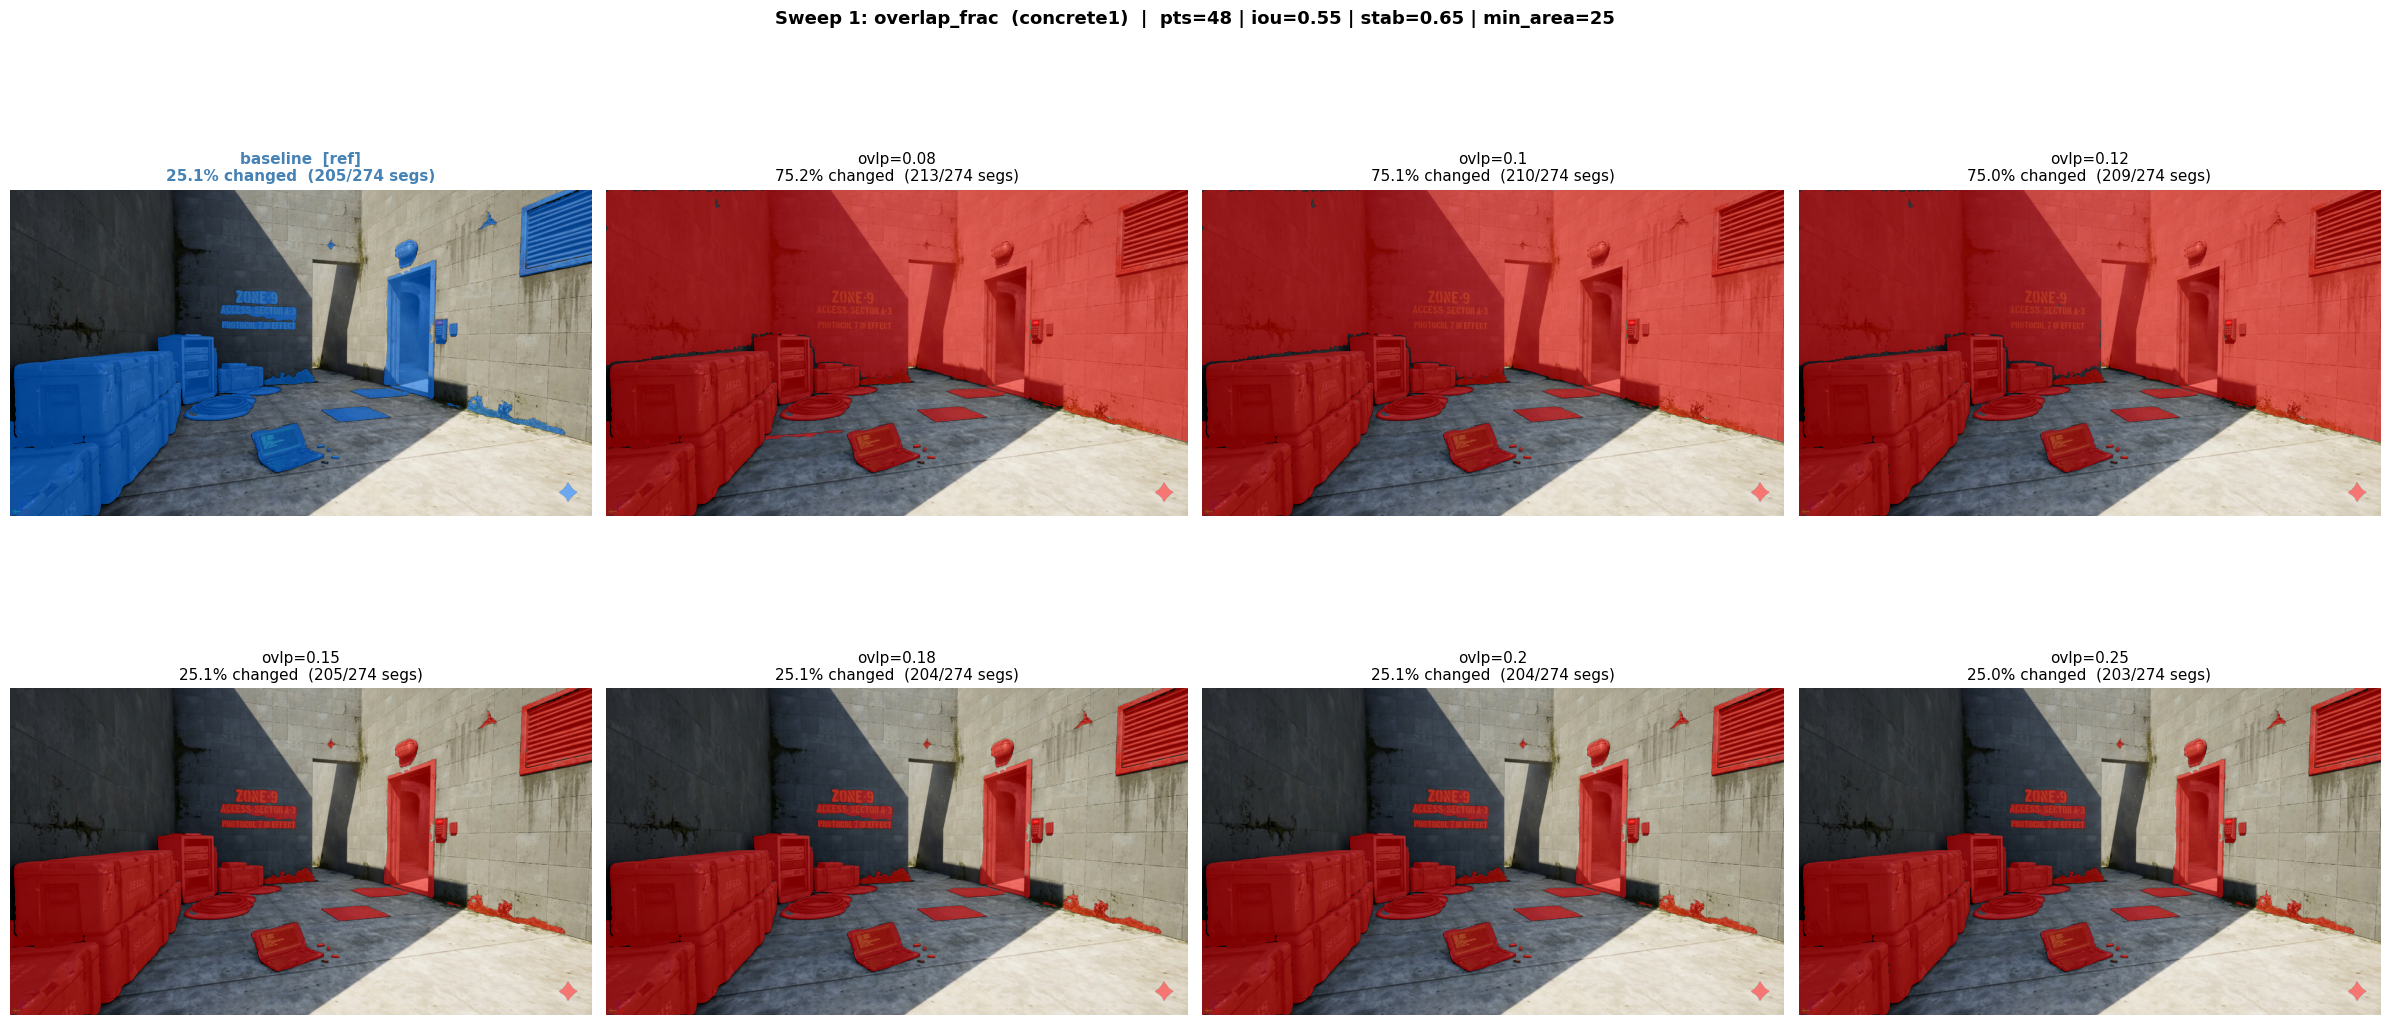

In [28]:
ovlp_values = [0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.25]

ovlp_results = {'baseline': baseline_result}
for i, v in enumerate(ovlp_values, 1):
    name = f'ovlp={v}'
    print(f'[{i}/{len(ovlp_values)}] {name} ...', flush=True)
    refined, n_segs, n_included, sam_failed = run_gescf(
        sam, edited_np, BASE_DIST, BASE_THR,
        **{**BASELINE_PARAMS, 'overlap_frac': v},
    )
    ovlp_results[name] = dict(mask=refined, failed=sam_failed, n_segs=n_segs, n_included=n_included)
    print(f'       included={n_included}/{n_segs}  changed={refined.mean()*100:.1f}%')

show_sweep(
    ovlp_results,
    f'Sweep 1: overlap_frac  ({DATASET})  |  {_fmt_fixed(skip=("overlap_frac",))}',
    cols=4, baseline_key='baseline',
)

## Sweep 2 — `points_per_side`

Focused around the strong `48` setting from your preferred combo.
Other params: `overlap_frac=0.15`, `pred_iou_thresh=0.55`, `stability_score_thresh=0.65`, `min_area=25`.

Higher values find thinner/smaller changed structures (ladder rungs, chair legs).
64 is still the expensive end of the sweep.


[1/5] pts=24 ...
       included=115/157  changed=27.0%
[2/5] pts=32 ...
       included=141/189  changed=25.2%
[3/5] pts=40 ...
       included=174/224  changed=25.9%
[4/5] pts=48 ...
       included=205/274  changed=25.1%
[5/5] pts=56 ...
       included=219/307  changed=25.0%


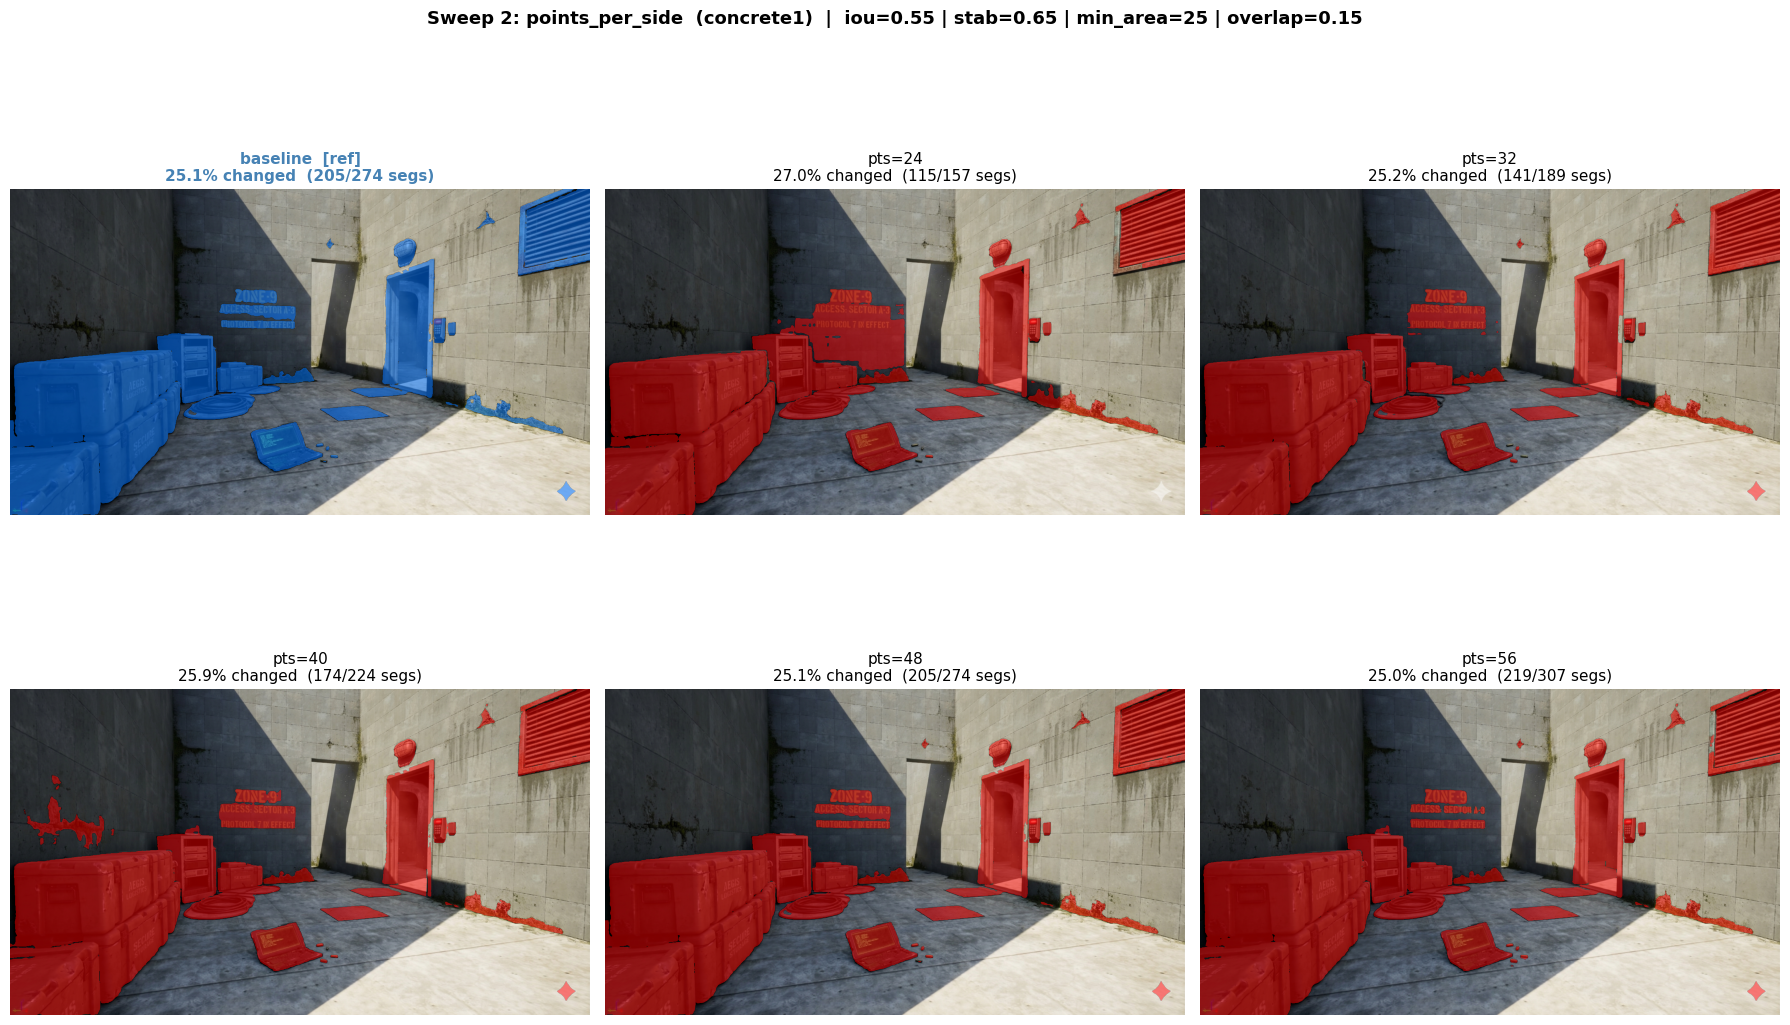

In [29]:
pts_values = [24, 32, 40, 48, 56]

pts_results = {'baseline': baseline_result}
for i, v in enumerate(pts_values, 1):
    name = f'pts={v}'
    print(f'[{i}/{len(pts_values)}] {name} ...', flush=True)
    refined, n_segs, n_included, sam_failed = run_gescf(
        sam, edited_np, BASE_DIST, BASE_THR,
        **{**BASELINE_PARAMS, 'points_per_side': v},
    )
    pts_results[name] = dict(mask=refined, failed=sam_failed, n_segs=n_segs, n_included=n_included)
    print(f'       included={n_included}/{n_segs}  changed={refined.mean()*100:.1f}%')

show_sweep(
    pts_results,
    f'Sweep 2: points_per_side  ({DATASET})  |  {_fmt_fixed(skip=("points_per_side",))}',
    cols=3, baseline_key='baseline',
)

## Sweep 3 — SAM quality filters (`pred_iou_thresh` + `stability_score_thresh`)

These two are swept together since they both control how strictly SAM filters its own segments.
This version is focused on the loose-quality region that looked good, while still covering the `0.70 / 0.75` combo.
Other params: `points_per_side=48`, `overlap_frac=0.15`, `min_area=25`.

Lower = more segments generated (some noisy). Higher = fewer, cleaner segments (may miss fine detail).

[1/5] iou=0.55 stab=0.65 ...
       included=205/274  changed=25.1%
[2/5] iou=0.6 stab=0.7 ...
       included=191/251  changed=25.0%
[3/5] iou=0.65 stab=0.72 ...
       included=170/224  changed=24.9%
[4/5] iou=0.7 stab=0.75 ...
       included=143/188  changed=24.6%
[5/5] iou=0.75 stab=0.8 ...
       included=122/162  changed=24.3%


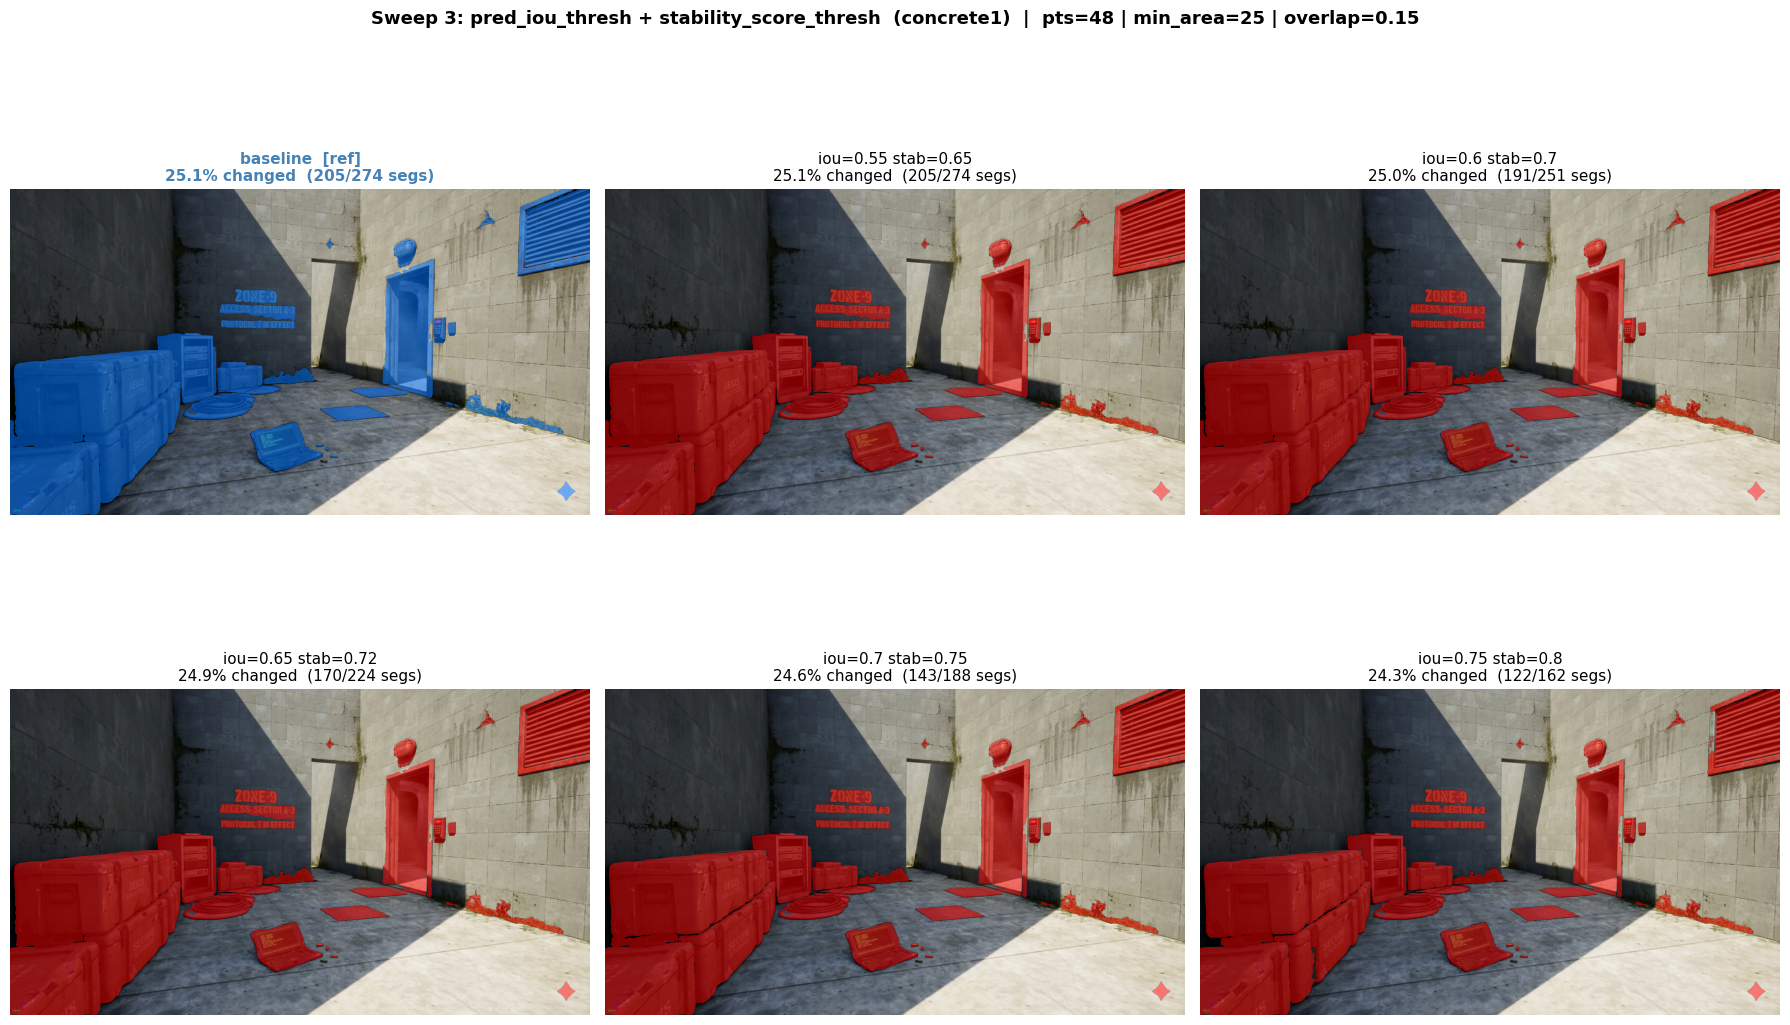

In [30]:
# (pred_iou_thresh, stability_score_thresh) pairs from loose to strict
quality_values = [
    (0.55, 0.65),
    (0.60, 0.70),
    (0.65, 0.72),
    (0.70, 0.75),
    (0.75, 0.80),
]

qual_results = {'baseline': baseline_result}
for i, (iou, stab) in enumerate(quality_values, 1):
    name = f'iou={iou} stab={stab}'
    print(f'[{i}/{len(quality_values)}] {name} ...', flush=True)
    refined, n_segs, n_included, sam_failed = run_gescf(
        sam, edited_np, BASE_DIST, BASE_THR,
        **{**BASELINE_PARAMS, 'pred_iou_thresh': iou, 'stability_score_thresh': stab},
    )
    qual_results[name] = dict(mask=refined, failed=sam_failed, n_segs=n_segs, n_included=n_included)
    print(f'       included={n_included}/{n_segs}  changed={refined.mean()*100:.1f}%')

show_sweep(
    qual_results,
    f'Sweep 3: pred_iou_thresh + stability_score_thresh  ({DATASET})  |  {_fmt_fixed(skip=("pred_iou_thresh", "stability_score_thresh"))}',
    cols=3, baseline_key='baseline',
)

## Sweep 4 — `min_mask_region_area`

Focused around the good small-area regime from your preferred combo.
Other params: `points_per_side=48`, `pred_iou_thresh=0.55`, `stability_score_thresh=0.65`, `overlap_frac=0.15`.

Controls the smallest segment (in pixels) that can be included.
Lower = keeps fine details like thin ladder rungs. Higher = cleaner mask but may miss small changed areas.


[1/7] min_area=10 ...
       included=216/286  changed=25.1%
[2/7] min_area=15 ...
       included=214/284  changed=25.1%
[3/7] min_area=20 ...
       included=208/277  changed=25.1%
[4/7] min_area=25 ...
       included=205/274  changed=25.1%
[5/7] min_area=35 ...
       included=203/272  changed=25.0%
[6/7] min_area=50 ...
       included=198/266  changed=25.0%
[7/7] min_area=75 ...
       included=197/265  changed=25.0%


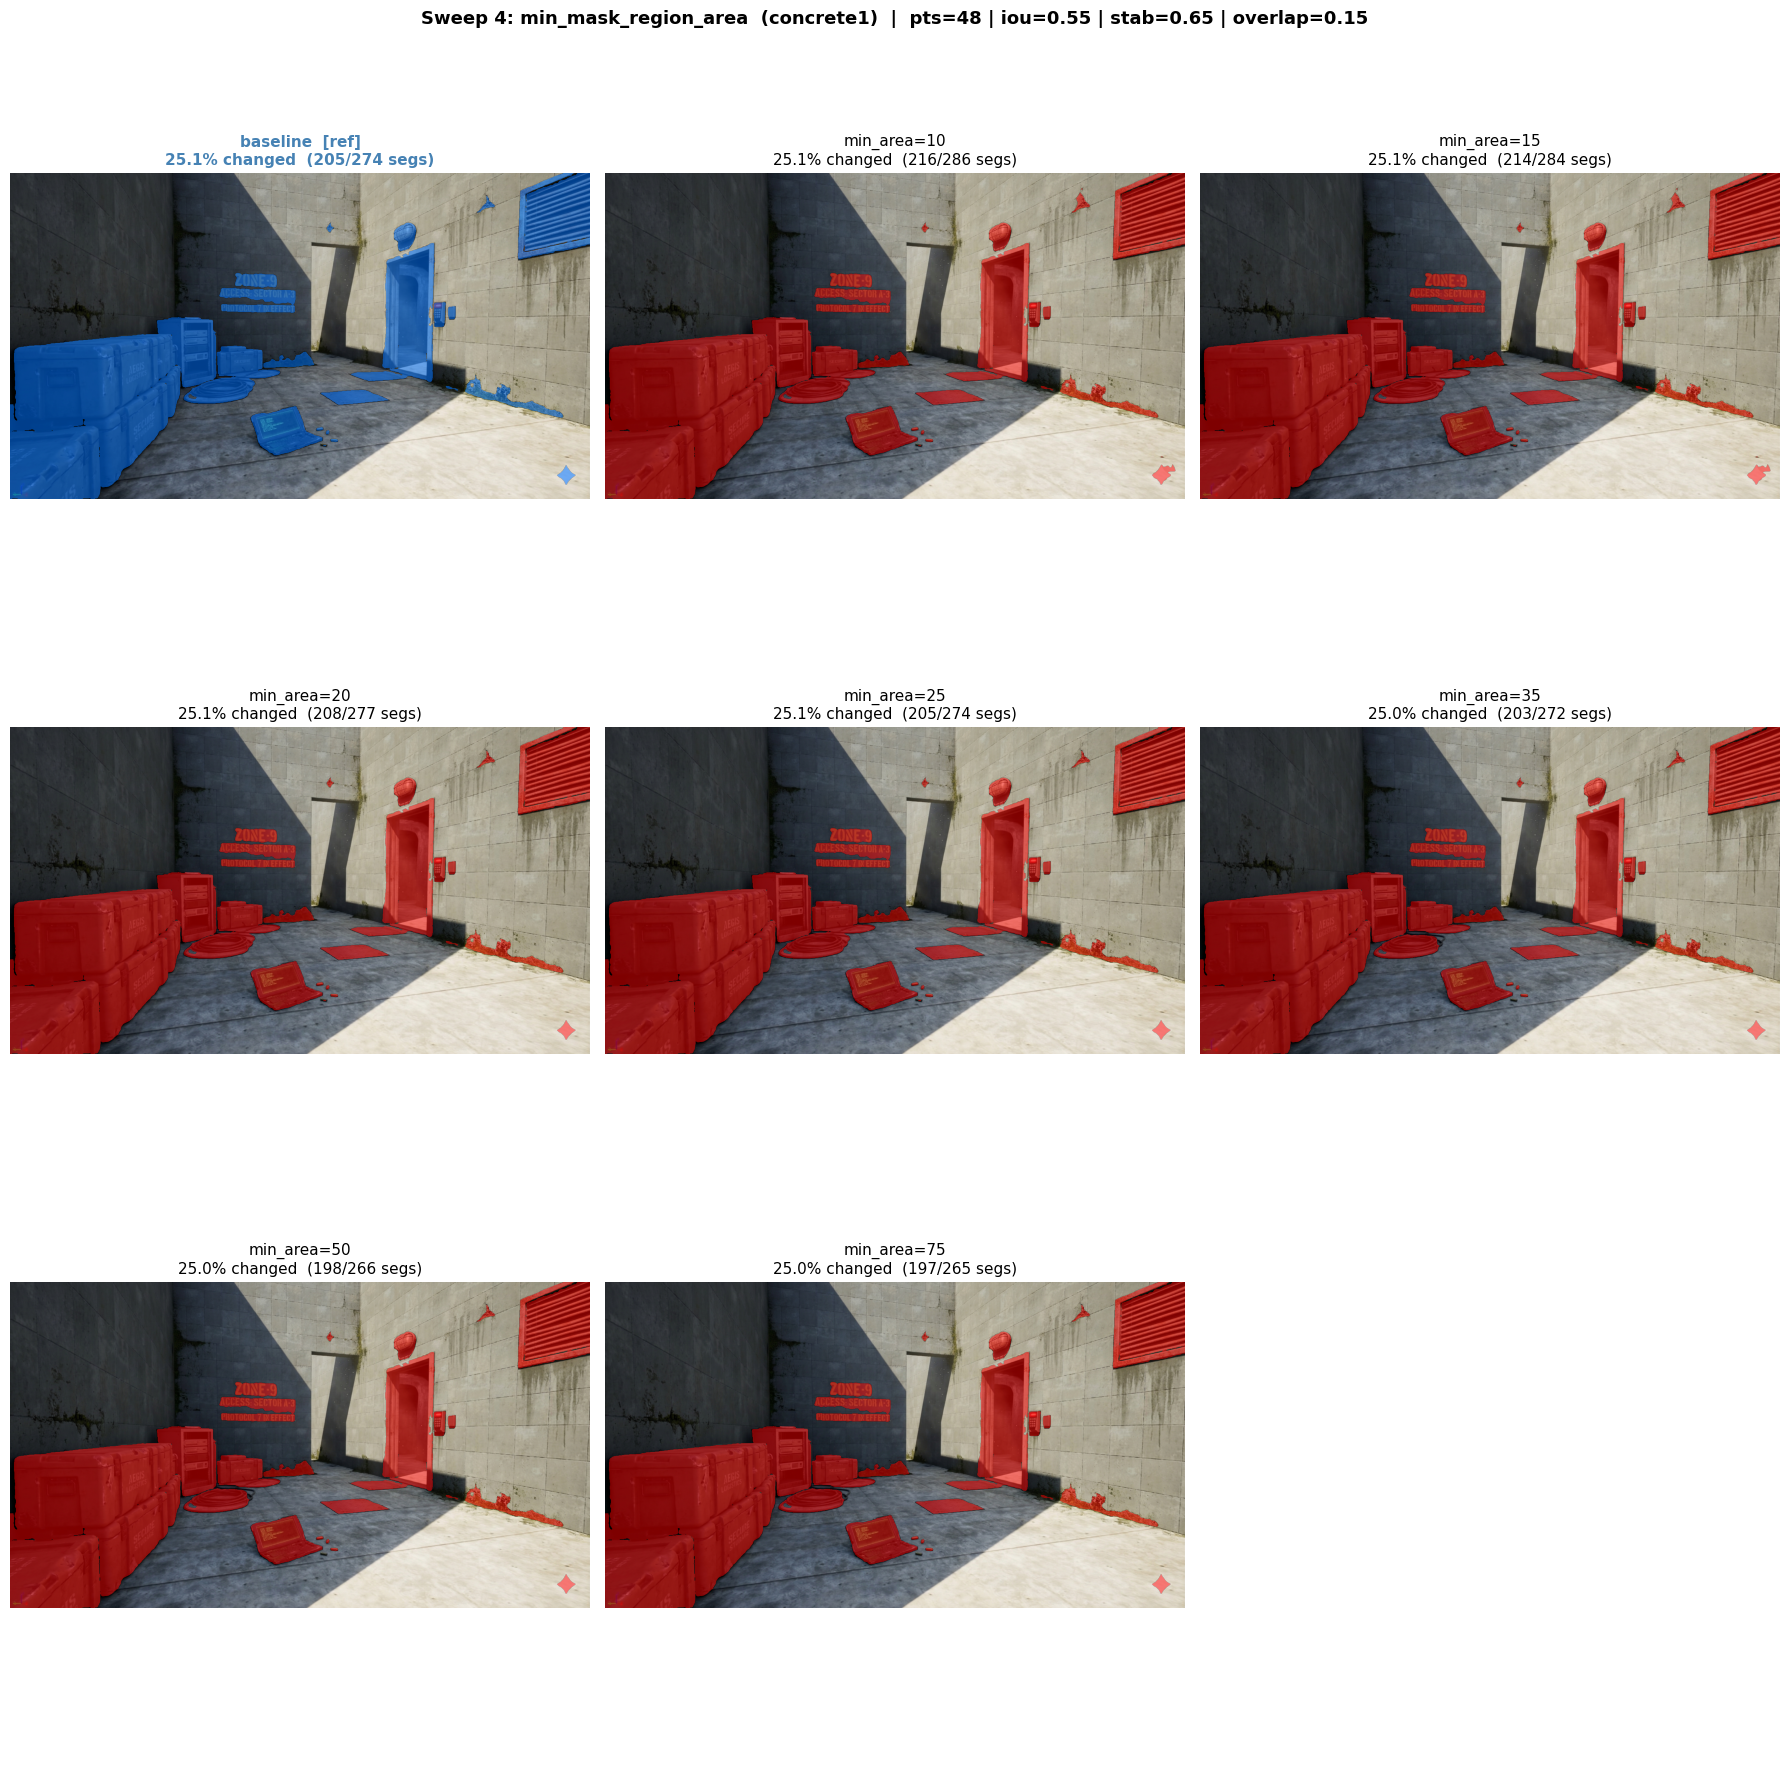

In [31]:
area_values = [10, 15, 20, 25, 35, 50, 75]

area_results = {'baseline': baseline_result}
for i, v in enumerate(area_values, 1):
    name = f'min_area={v}'
    print(f'[{i}/{len(area_values)}] {name} ...', flush=True)
    refined, n_segs, n_included, sam_failed = run_gescf(
        sam, edited_np, BASE_DIST, BASE_THR,
        **{**BASELINE_PARAMS, 'min_mask_region_area': v},
    )
    area_results[name] = dict(mask=refined, failed=sam_failed, n_segs=n_segs, n_included=n_included)
    print(f'       included={n_included}/{n_segs}  changed={refined.mean()*100:.1f}%')

show_sweep(
    area_results,
    f'Sweep 4: min_mask_region_area  ({DATASET})  |  {_fmt_fixed(skip=("min_mask_region_area",))}',
    cols=3, baseline_key='baseline',
)

## Combos

Compare the shortlisted configs you liked from the focused sweeps above.
These are grouped from combos, SAM quality, overlap, and min-area.

[1/11] baseline ...
       included=13/323  changed=2.8%
[2/11] 1 ...
       included=12/296  changed=2.8%
[3/11] 2 ...
       included=25/360  changed=2.9%
[4/11] 3 ...
       included=21/353  changed=2.9%
[5/11] 4 ...
       included=13/331  changed=2.8%
[6/11] 5 ...
       included=6/257  changed=1.9%
[7/11] 6 ...
       included=6/257  changed=1.9%
[8/11] 7 ...
       included=11/232  changed=4.4%
[9/11] 8 ...
       included=11/230  changed=4.4%
[10/11] 9 ...
       included=9/215  changed=2.6%
[11/11] 10 ...
       included=8/211  changed=2.4%


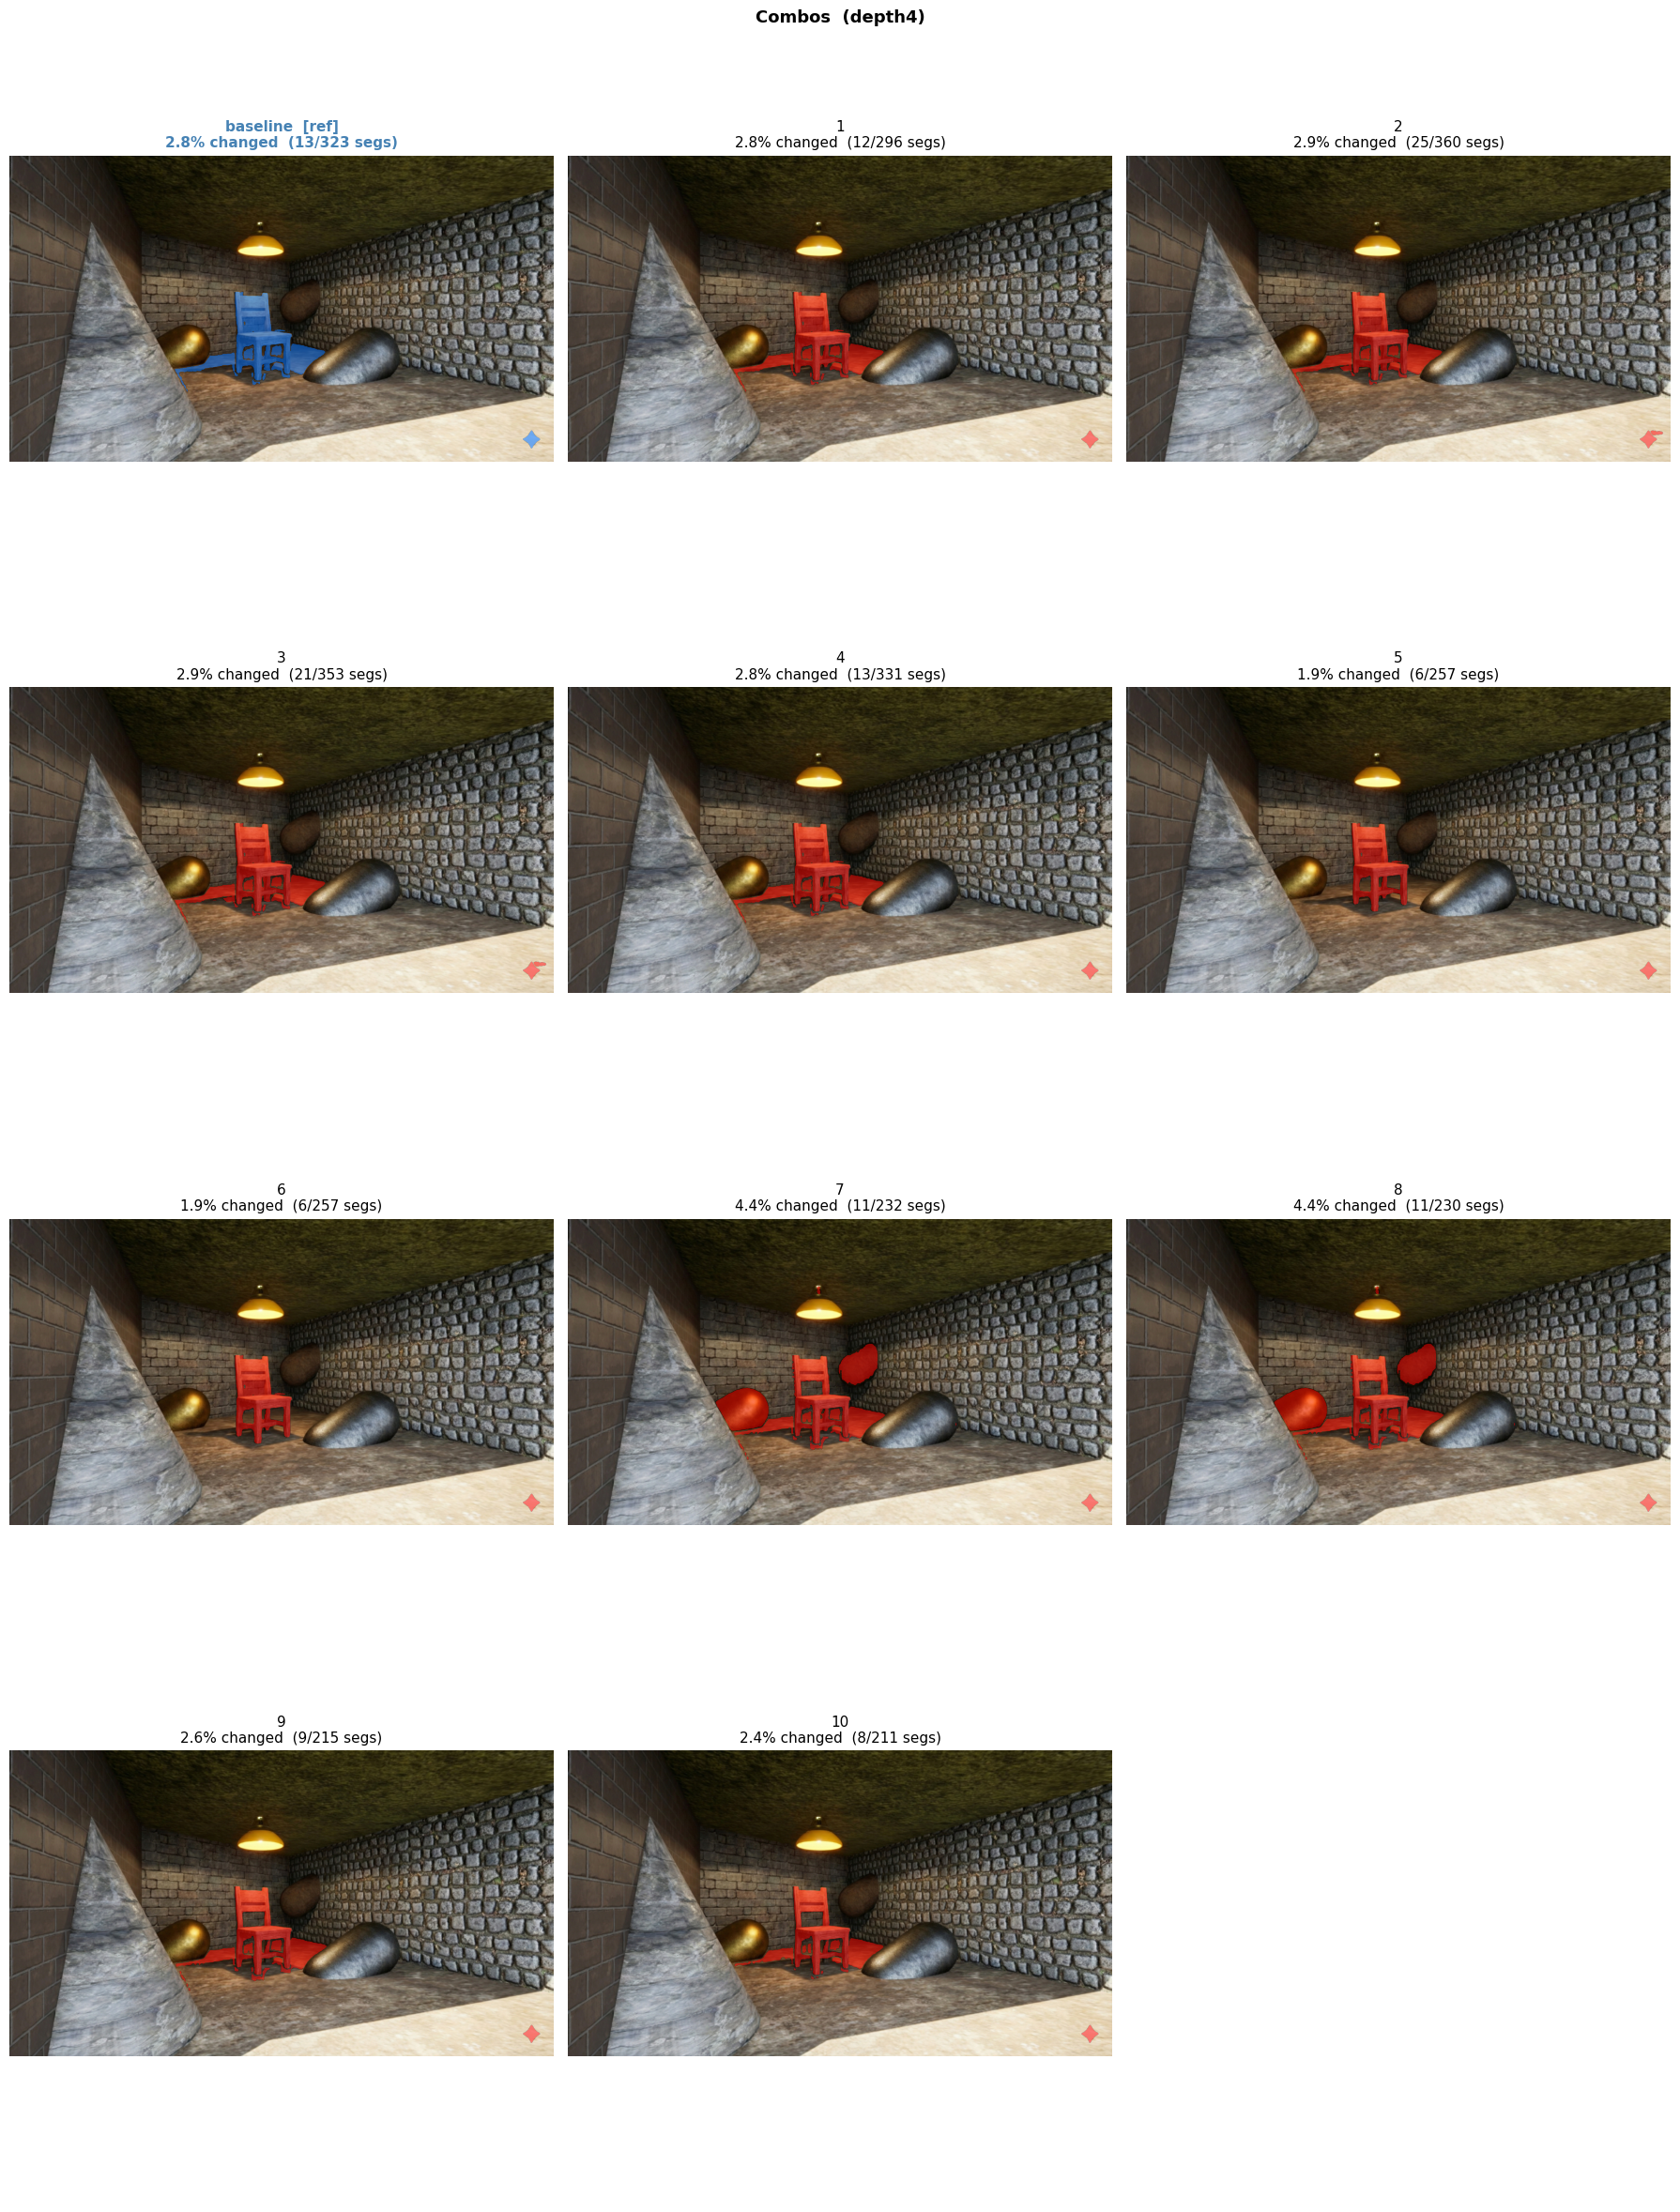

In [54]:
combo_configs = {
    'baseline':     BASELINE_PARAMS,
    '1': dict(
        points_per_side=48, pred_iou_thresh=0.60,
        stability_score_thresh=0.70, min_mask_region_area=25, overlap_frac=0.15,
    ),
    '2': dict(
        points_per_side=48, pred_iou_thresh=0.45,
        stability_score_thresh=0.55, min_mask_region_area=25, overlap_frac=0.15,
    ),
    '3': dict(
        points_per_side=48, pred_iou_thresh=0.50,
        stability_score_thresh=0.55, min_mask_region_area=25, overlap_frac=0.15,
    ),
    '4': dict(
        points_per_side=48, pred_iou_thresh=0.55,
        stability_score_thresh=0.60, min_mask_region_area=25, overlap_frac=0.18,
    ),
    '5': dict(
        points_per_side=48, pred_iou_thresh=0.70,
        stability_score_thresh=0.75, min_mask_region_area=25, overlap_frac=0.20,
    ),
    '6': dict(
        points_per_side=48, pred_iou_thresh=0.70,
        stability_score_thresh=0.75, min_mask_region_area=25, overlap_frac=0.25,
    ),
    '7': dict(
        points_per_side=32, pred_iou_thresh=0.50,
        stability_score_thresh=0.55, min_mask_region_area=10, overlap_frac=0.15,
    ),
    '8': dict(
        points_per_side=32, pred_iou_thresh=0.50,
        stability_score_thresh=0.55, min_mask_region_area=15, overlap_frac=0.25,
    ),
    '9': dict(
        points_per_side=32, pred_iou_thresh=0.55,
        stability_score_thresh=0.60, min_mask_region_area=20, overlap_frac=0.25,
    ),
    '10': dict(
        points_per_side=32, pred_iou_thresh=0.55,
        stability_score_thresh=0.65, min_mask_region_area=15, overlap_frac=0.15,
    )
    
}

combo_results = {}
for i, (name, cfg) in enumerate(combo_configs.items(), 1):
    print(f'[{i}/{len(combo_configs)}] {name} ...', flush=True)
    refined, n_segs, n_included, sam_failed = run_gescf(sam, edited_np, BASE_DIST, BASE_THR, **cfg)
    combo_results[name] = dict(mask=refined, failed=sam_failed, n_segs=n_segs, n_included=n_included)
    print(f'       included={n_included}/{n_segs}  changed={refined.mean()*100:.1f}%')

show_sweep(combo_results, f'Combos  ({DATASET})', cols=3, baseline_key='baseline')


In [33]:
del sam
gc.collect()
if device == 'cuda': torch.cuda.empty_cache()
print('SAM unloaded.')


SAM unloaded.
